### EDA

In [1]:
import pandas
import seaborn as sns

In [2]:
data = pandas.read_csv("../data/updated_pollution_dataset.csv")

In [3]:
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 390.8 KB


In [5]:
data.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


distribution of the target column

In [6]:
target_col = data.columns[-1]

distribution = (
    data[target_col]
    .value_counts(dropna=False)
    .rename_axis(target_col)
    .reset_index(name="count")
)

distribution["percentage"] = (distribution["count"] / len(data) * 100).round(2)
distribution

,Air Quality,count,percentage
0,Good,2000,40.0
1,Moderate,1500,30.0
2,Poor,1000,20.0
3,Hazardous,500,10.0


duplicated rows

In [7]:
data[data.duplicated()]

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality


missing values

In [8]:
data.isna().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

missing cells

In [9]:
data.isna().sum().sum()

np.int64(0)

TARGET COLUMN ENCODING

In [10]:
quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)


data[target_col] = data[target_col].astype("int8")
data[[target_col]].head()

,Air Quality
0,2
1,2
2,2
3,3
4,3


In [12]:
data.head()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,3
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,3


<Axes: >

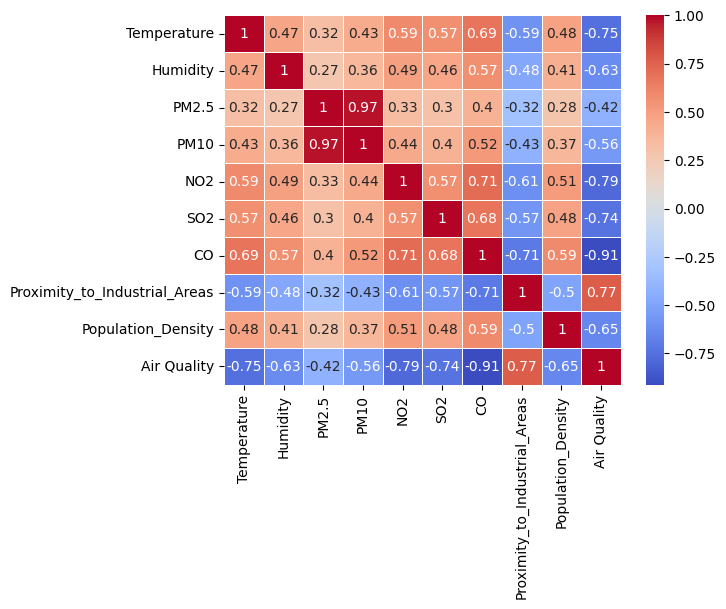

In [11]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=0.5)